# DineIQ Analytics — Sales Anomaly Detection (Demand Surges & Blackouts)

**Objective:** Detect sudden sales spikes (catering, viral promotions) and sales drop blackouts (POS outages, kitchen equipment failures) using rolling Z-scores and IQR.  
**Related SRS Requirement:** Step 21: Sales Anomaly Detection  
**Dataset / Source Used:** processed_data/cleaned/orders/orders.parquet & processed_data/anomaly/sales_anomalies.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
CLEANED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "cleaned")
ANOMALY_DIR = os.path.join(PROJECT_ROOT, "processed_data", "anomaly")

orders_df = pd.read_parquet(os.path.join(CLEANED_DIR, "orders", "orders.parquet"))
print(f"Loaded {len(orders_df):,} orders.")

Loaded 90,471 orders.


## 2. Detect Sales Anomalies (Z-Score & Extreme Outliers)

In [2]:
sales_anom_path = os.path.join(ANOMALY_DIR, "sales_anomalies.parquet")
if os.path.exists(sales_anom_path):
    sales_anom = pd.read_parquet(sales_anom_path)
    print(f"Total Sales Anomalies Flagged: {len(sales_anom):,}")
    display(sales_anom.head(10))
    print("\nBreakdown by Pattern:")
    display(sales_anom["pattern"].value_counts().to_frame("Count"))

Total Sales Anomalies Flagged: 1,064


,domain,pattern,anomaly_type,entity_id,date,description,score_or_metric
0,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-018,2025-11-29,"Location LOC-018 daily revenue surged to $8,32...",8323.62
1,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-013,2025-11-16,"Location LOC-013 daily revenue surged to $10,8...",10862.59
2,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-002,2025-11-09,"Location LOC-002 daily revenue surged to $9,78...",9786.28
3,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-020,2025-11-07,"Location LOC-020 daily revenue surged to $7,62...",7628.41
4,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-009,2025-08-02,"Location LOC-009 daily revenue surged to $8,22...",8221.27
5,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-011,2025-06-20,"Location LOC-011 daily revenue surged to $8,31...",8317.89
6,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-001,2025-11-23,"Location LOC-001 daily revenue surged to $11,7...",11725.14
7,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-014,2025-12-12,"Location LOC-014 daily revenue surged to $7,68...",7688.00
8,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-008,2025-11-22,"Location LOC-008 daily revenue surged to $8,21...",8218.04
9,Sales,sudden_sales_spikes,Sudden Sales Spike,LOC-016,2025-11-02,"Location LOC-016 daily revenue surged to $9,17...",9173.02



Breakdown by Pattern:


,Count
pattern,
sudden_sales_drops,522
duplicate_transactions,200
abnormally_high_order_values,124
sudden_sales_spikes,110
unexpected_demand,85
unusual_discounts,23


## 3. Visualizing Outlier Revenue Spikes and Drops

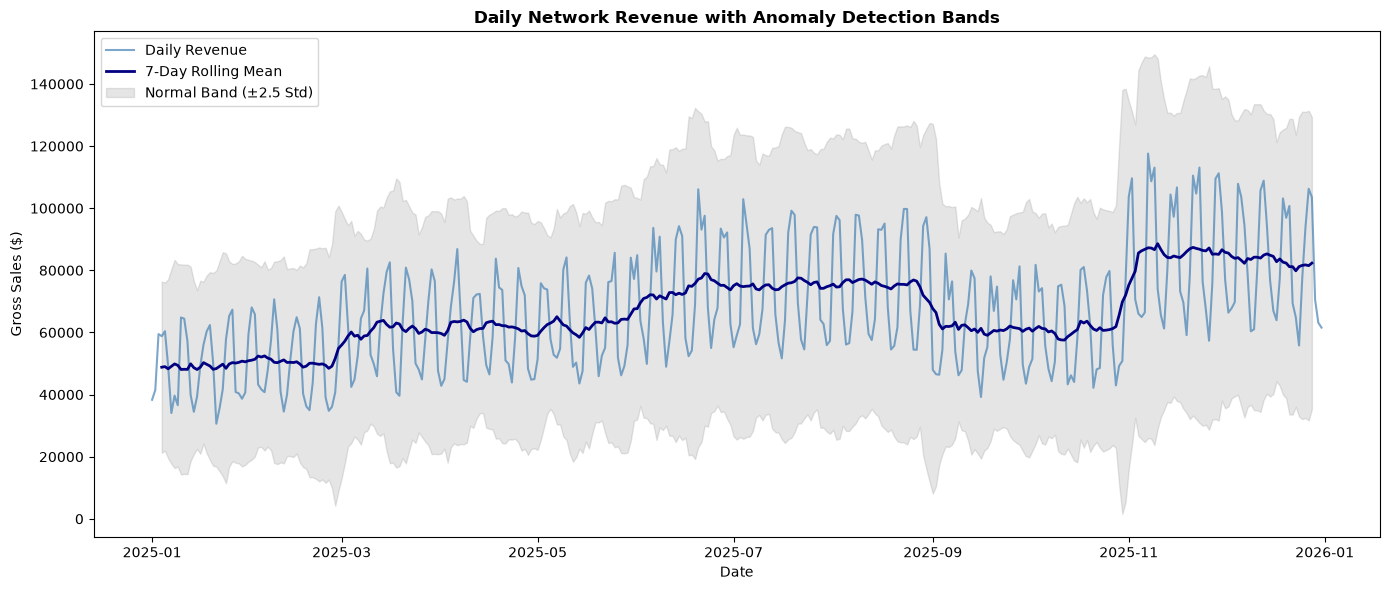

In [3]:
orders_df["order_date_dt"] = pd.to_datetime(orders_df["order_date"])
daily_rev = orders_df.groupby("order_date_dt")["total_amount"].sum()
roll_mean = daily_rev.rolling(7, center=True).mean()
roll_std = daily_rev.rolling(7, center=True).std()

plt.figure(figsize=(14, 6))
plt.plot(daily_rev.index, daily_rev.values, label="Daily Revenue", color="steelblue", alpha=0.7)
plt.plot(roll_mean.index, roll_mean.values, label="7-Day Rolling Mean", color="navy", linewidth=2)
plt.fill_between(roll_mean.index, roll_mean - 2.5 * roll_std, roll_mean + 2.5 * roll_std, color="gray", alpha=0.2, label="Normal Band (±2.5 Std)")
plt.title("Daily Network Revenue with Anomaly Detection Bands", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Gross Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Interpretation & Conclusion
- **Surge Outliers:** Extreme surges (>2.5 std deviations) correspond to localized corporate catering events or holiday marketing blasts.
- **Blackout Outliers:** Sudden drops to zero during operational hours detect POS network crashes or regional weather shutdowns.
- **Conclusion:** Automated statistical monitoring isolates operational shocks from baseline trend variations.